In [153]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
sns.set_theme(style="whitegrid",font_scale=1.2)
from scipy.stats import chi2_contingency
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.base import BaseEstimator, TransformerMixin
import optuna
from optuna.samplers import TPESampler
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
optuna.logging.set_verbosity(optuna.logging.WARNING) 


In [2]:
df = pd.read_csv("data/train.csv")

In [3]:
df.columns

Index(['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
       'spectral_type', 'galaxy_population', 'class'],
      dtype='object')

In [4]:
df.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [5]:
df = df.drop("id",axis =1)
numeric_cols = [n for n in df.columns if df[n].dtype!="object"]
object_cols = [n for n in df.columns if n not in numeric_cols and n!="class"]

In [6]:
all_na = df.isna().sum()
pd.concat([all_na, all_na/df.shape[0]], axis=1)

,0,1
alpha,0,0.0
delta,0,0.0
u,0,0.0
g,0,0.0
r,0,0.0
i,0,0.0
z,0,0.0
redshift,0,0.0
spectral_type,0,0.0
galaxy_population,0,0.0


## EDA

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_96765/3940967821.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df["class"].value_counts(), palette="Blues")


<Axes: xlabel='class', ylabel='count'>

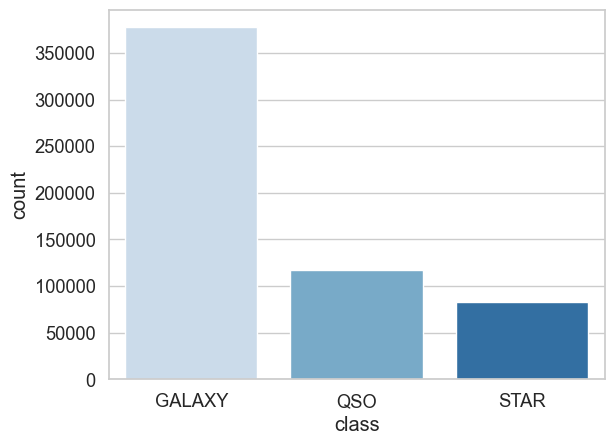

In [7]:
sns.barplot(df["class"].value_counts(), palette="Blues")


/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_96765/1924364925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y= n, x="class", ax=axes[0], palette="Blues")


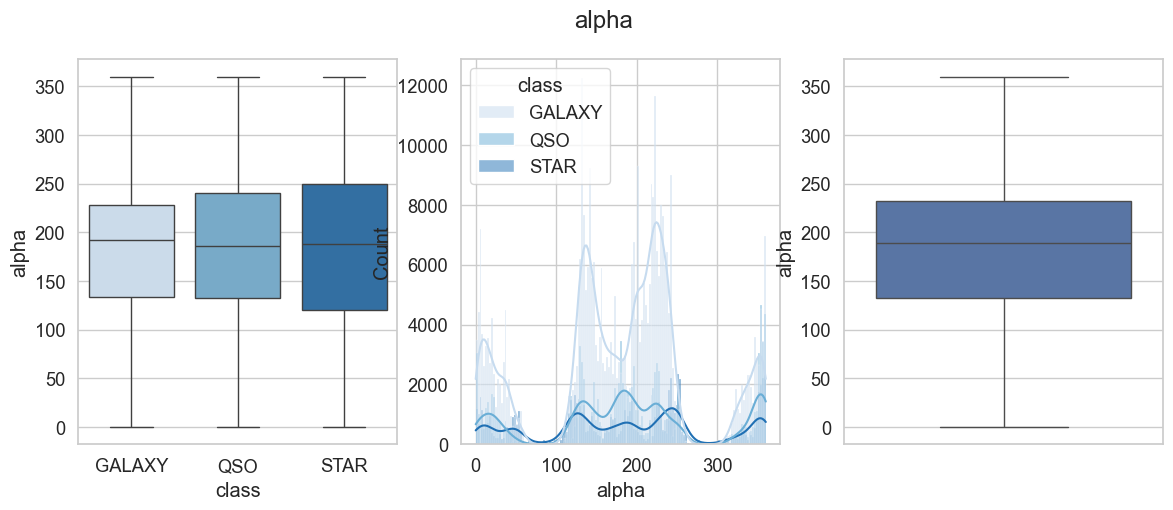

<Figure size 640x480 with 0 Axes>

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_96765/1924364925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y= n, x="class", ax=axes[0], palette="Blues")


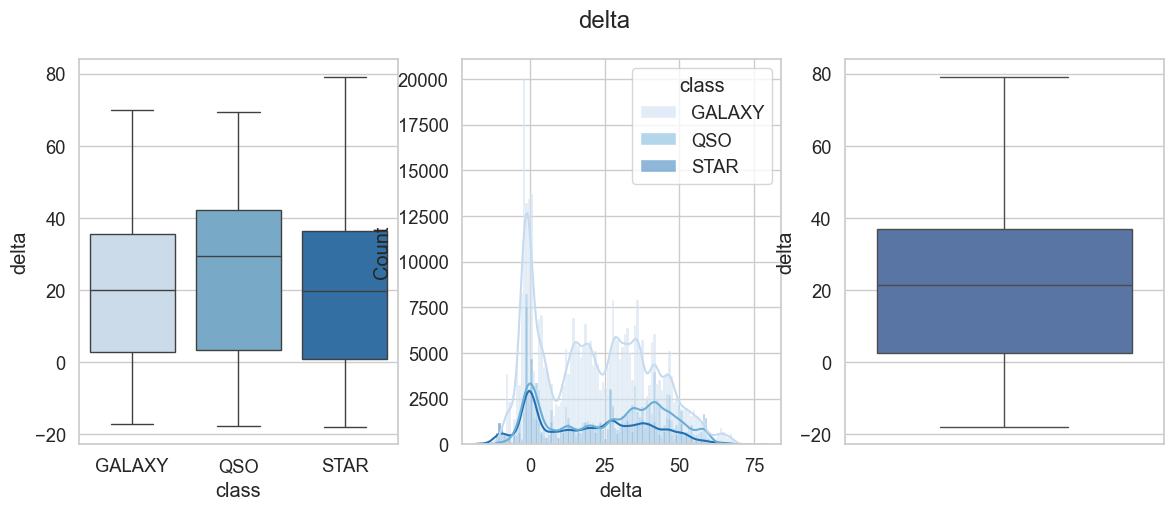

<Figure size 640x480 with 0 Axes>

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_96765/1924364925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y= n, x="class", ax=axes[0], palette="Blues")


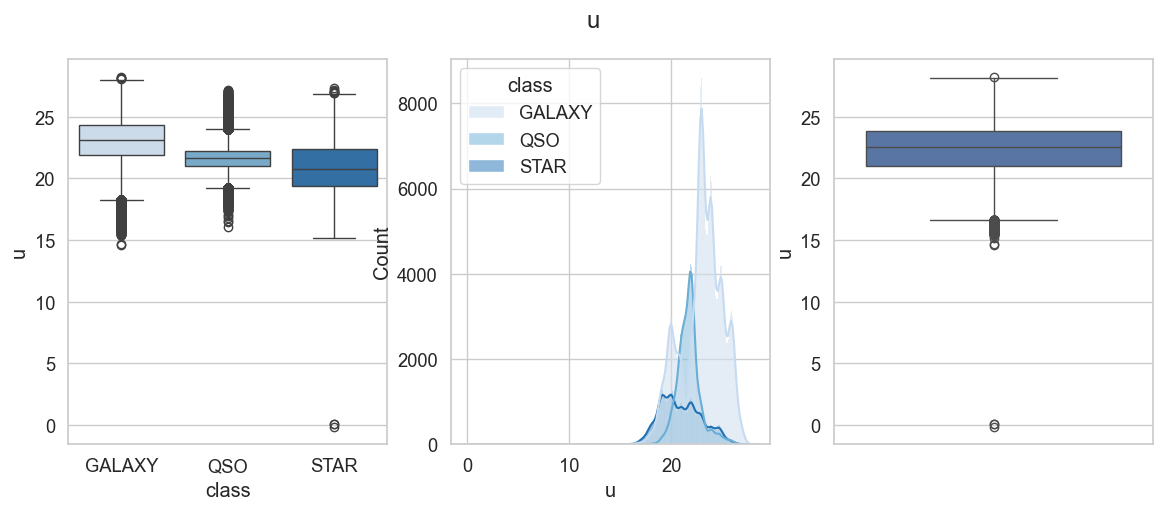

<Figure size 640x480 with 0 Axes>

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_96765/1924364925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y= n, x="class", ax=axes[0], palette="Blues")


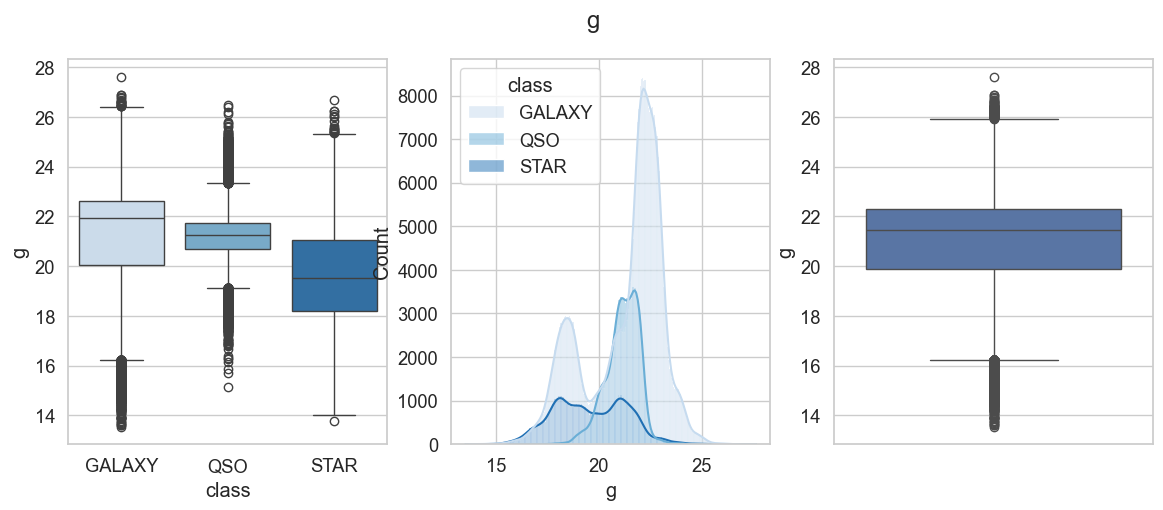

<Figure size 640x480 with 0 Axes>

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_96765/1924364925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y= n, x="class", ax=axes[0], palette="Blues")


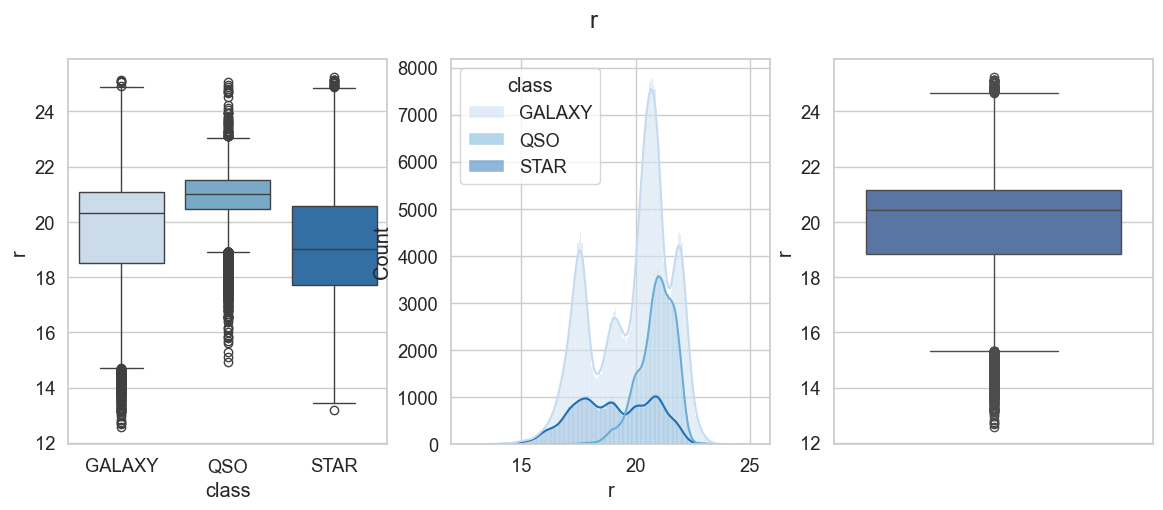

<Figure size 640x480 with 0 Axes>

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_96765/1924364925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y= n, x="class", ax=axes[0], palette="Blues")


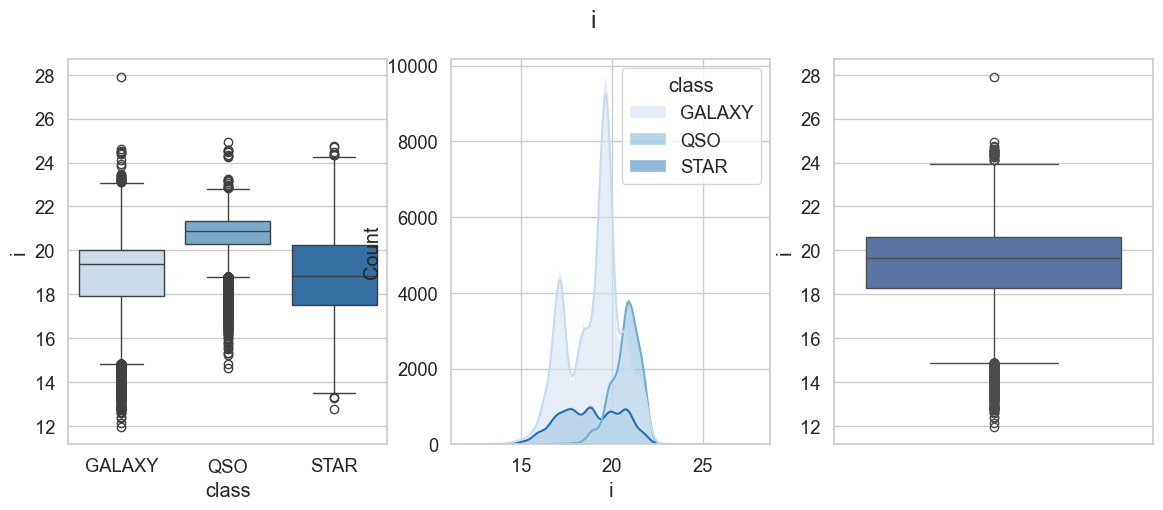

<Figure size 640x480 with 0 Axes>

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_96765/1924364925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y= n, x="class", ax=axes[0], palette="Blues")


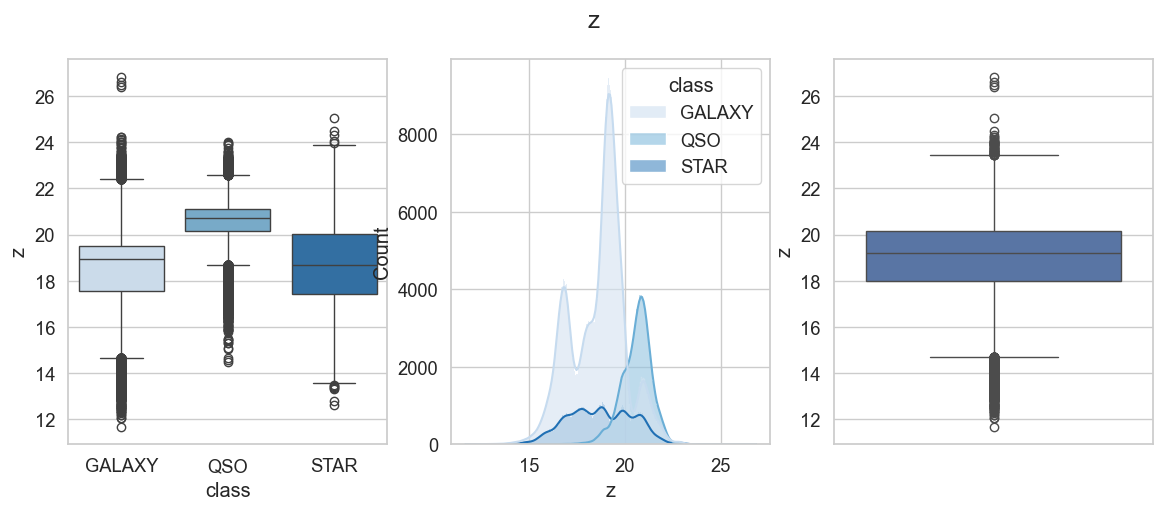

<Figure size 640x480 with 0 Axes>

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_96765/1924364925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y= n, x="class", ax=axes[0], palette="Blues")


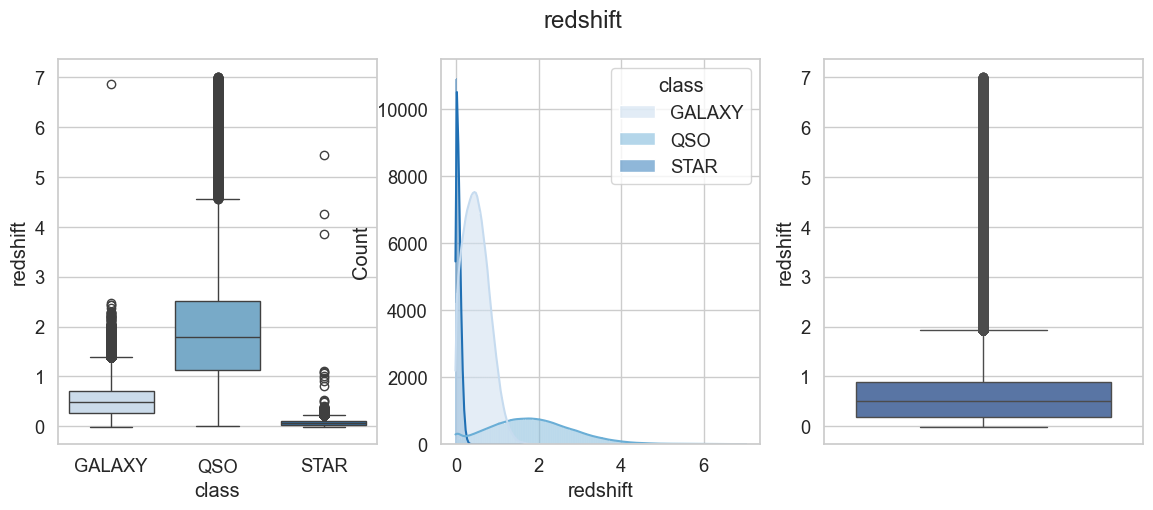

<Figure size 640x480 with 0 Axes>

In [8]:
for n in numeric_cols:
    fig, axes = plt.subplots(1,3, figsize = (14,5))
    plt.figure()
    sns.boxplot(data=df, y= n, x="class", ax=axes[0], palette="Blues")
    sns.histplot(data=df, x= n, hue="class", ax=axes[1], palette="Blues", kde=True)
    sns.boxplot(data=df, y= n, ax=axes[2])
    fig.suptitle(n)
    plt.show()

* redshift looks like one of the most strongest potential predictors
* z and i may be also 
*  u has a long left tail

             alpha      delta         u          g          r          i  \
78641    20.935421   0.992029  0.071698  23.227556  21.641705  20.476371   
523685  135.307766  56.790901  0.114522  21.019313  20.415736  20.048254   

                z  redshift spectral_type galaxy_population class  
78641   20.070532  4.264182             M        Blue_Cloud  STAR  
523685  19.712076  5.445217           G/K        Blue_Cloud  STAR  


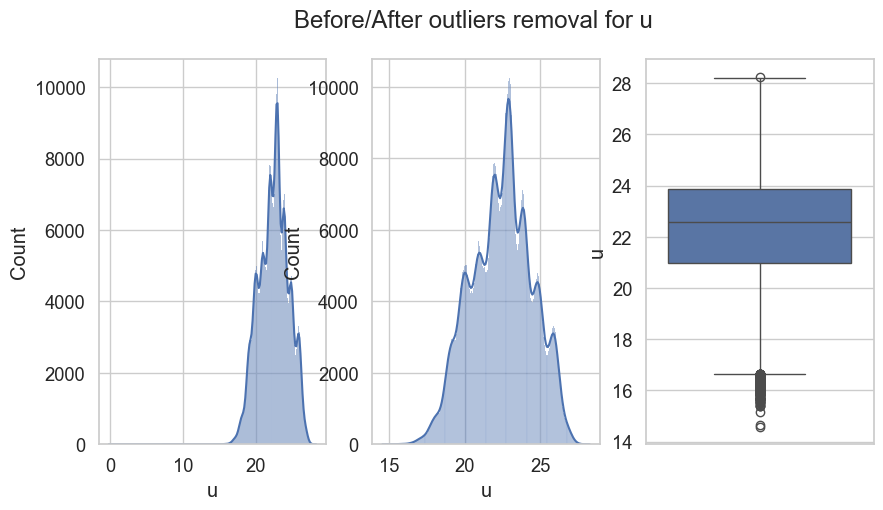

In [9]:
# check u outliers and remove them
print(df[(df["u"]>=0) & (df["u"]<2.5)])
fig, axes = plt.subplots(1,3, figsize=(10,5))
sns.histplot(data = df, x="u", ax=axes[0], kde=True)
sns.histplot(data = df[df["u"]>2.5], x="u", ax=axes[1], kde=True)
sns.boxplot(data=df[df["u"]>2.5],y="u", ax=axes[2])

fig.suptitle("Before/After outliers removal for u")
plt.show()
# df = df[(df["u"]>2.5)]


             alpha     delta          u          g         r          i  \
220346  146.646496  16.89544  18.933514  17.102931  17.15289  27.910853   

                z  redshift spectral_type galaxy_population   class  
220346  26.485183  0.514326           O/B        Blue_Cloud  GALAXY  


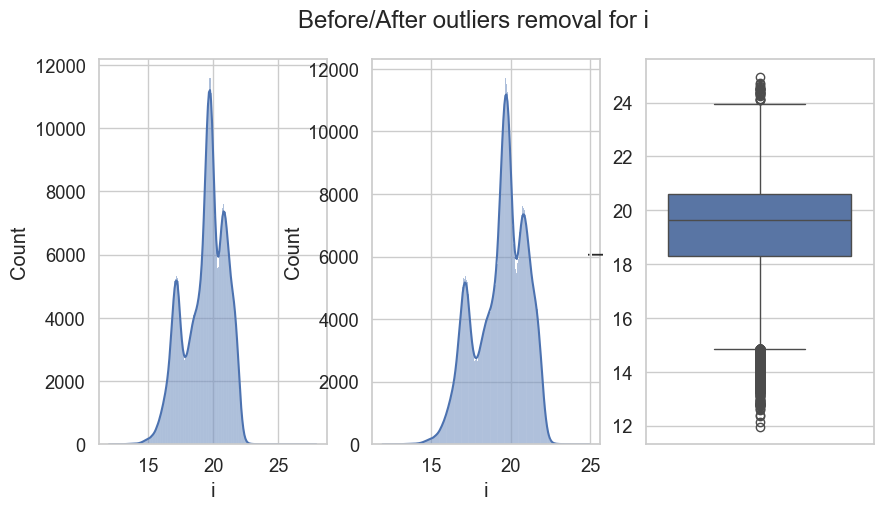

In [10]:
# check i outliers and remove them
print(df[(df["i"]>=27)])
fig, axes = plt.subplots(1,3, figsize=(10,5))
sns.histplot(data = df, x="i", ax=axes[0], kde=True)
sns.histplot(data = df[df["i"]<27], x="i", ax=axes[1], kde=True)
sns.boxplot(data=df[df["i"]<27],y="i", ax=axes[2])
fig.suptitle("Before/After outliers removal for i")
plt.show()
# df = df[(df["i"]<27)]


             alpha      delta          u          g          r          i  \
323343  230.908564  46.161903  25.613179  22.398653  20.200765  19.613506   

                z  redshift spectral_type galaxy_population   class  
323343  18.802087  6.860273             M      Red_Sequence  GALAXY  


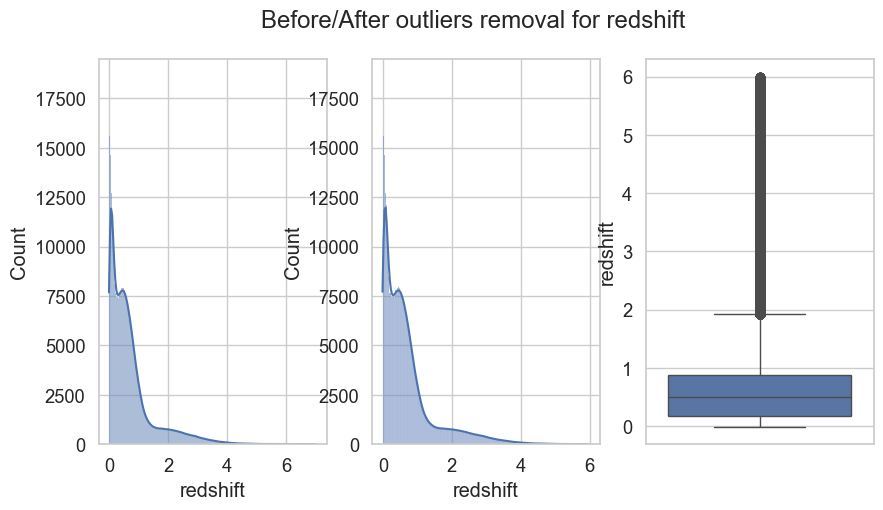

In [11]:
# check redshift outliers and remove them
print(df[(df["redshift"]>=6) & (df["class"]=="GALAXY")])
fig, axes = plt.subplots(1,3, figsize=(10,5))
sns.histplot(data = df, x="redshift", ax=axes[0], kde=True)
sns.histplot(data = df[df["redshift"]<6], x="redshift", ax=axes[1], kde=True)
sns.boxplot(data=df[df["redshift"]<6],y="redshift", ax=axes[2])
fig.suptitle("Before/After outliers removal for redshift")
plt.show()
condition = ((df["redshift"]>=6) & (df["class"]=="GALAXY"))
# df = df[~condition]
# df = df[(df["redshift"]<=6) & (df["class"]=="GALAXY")]


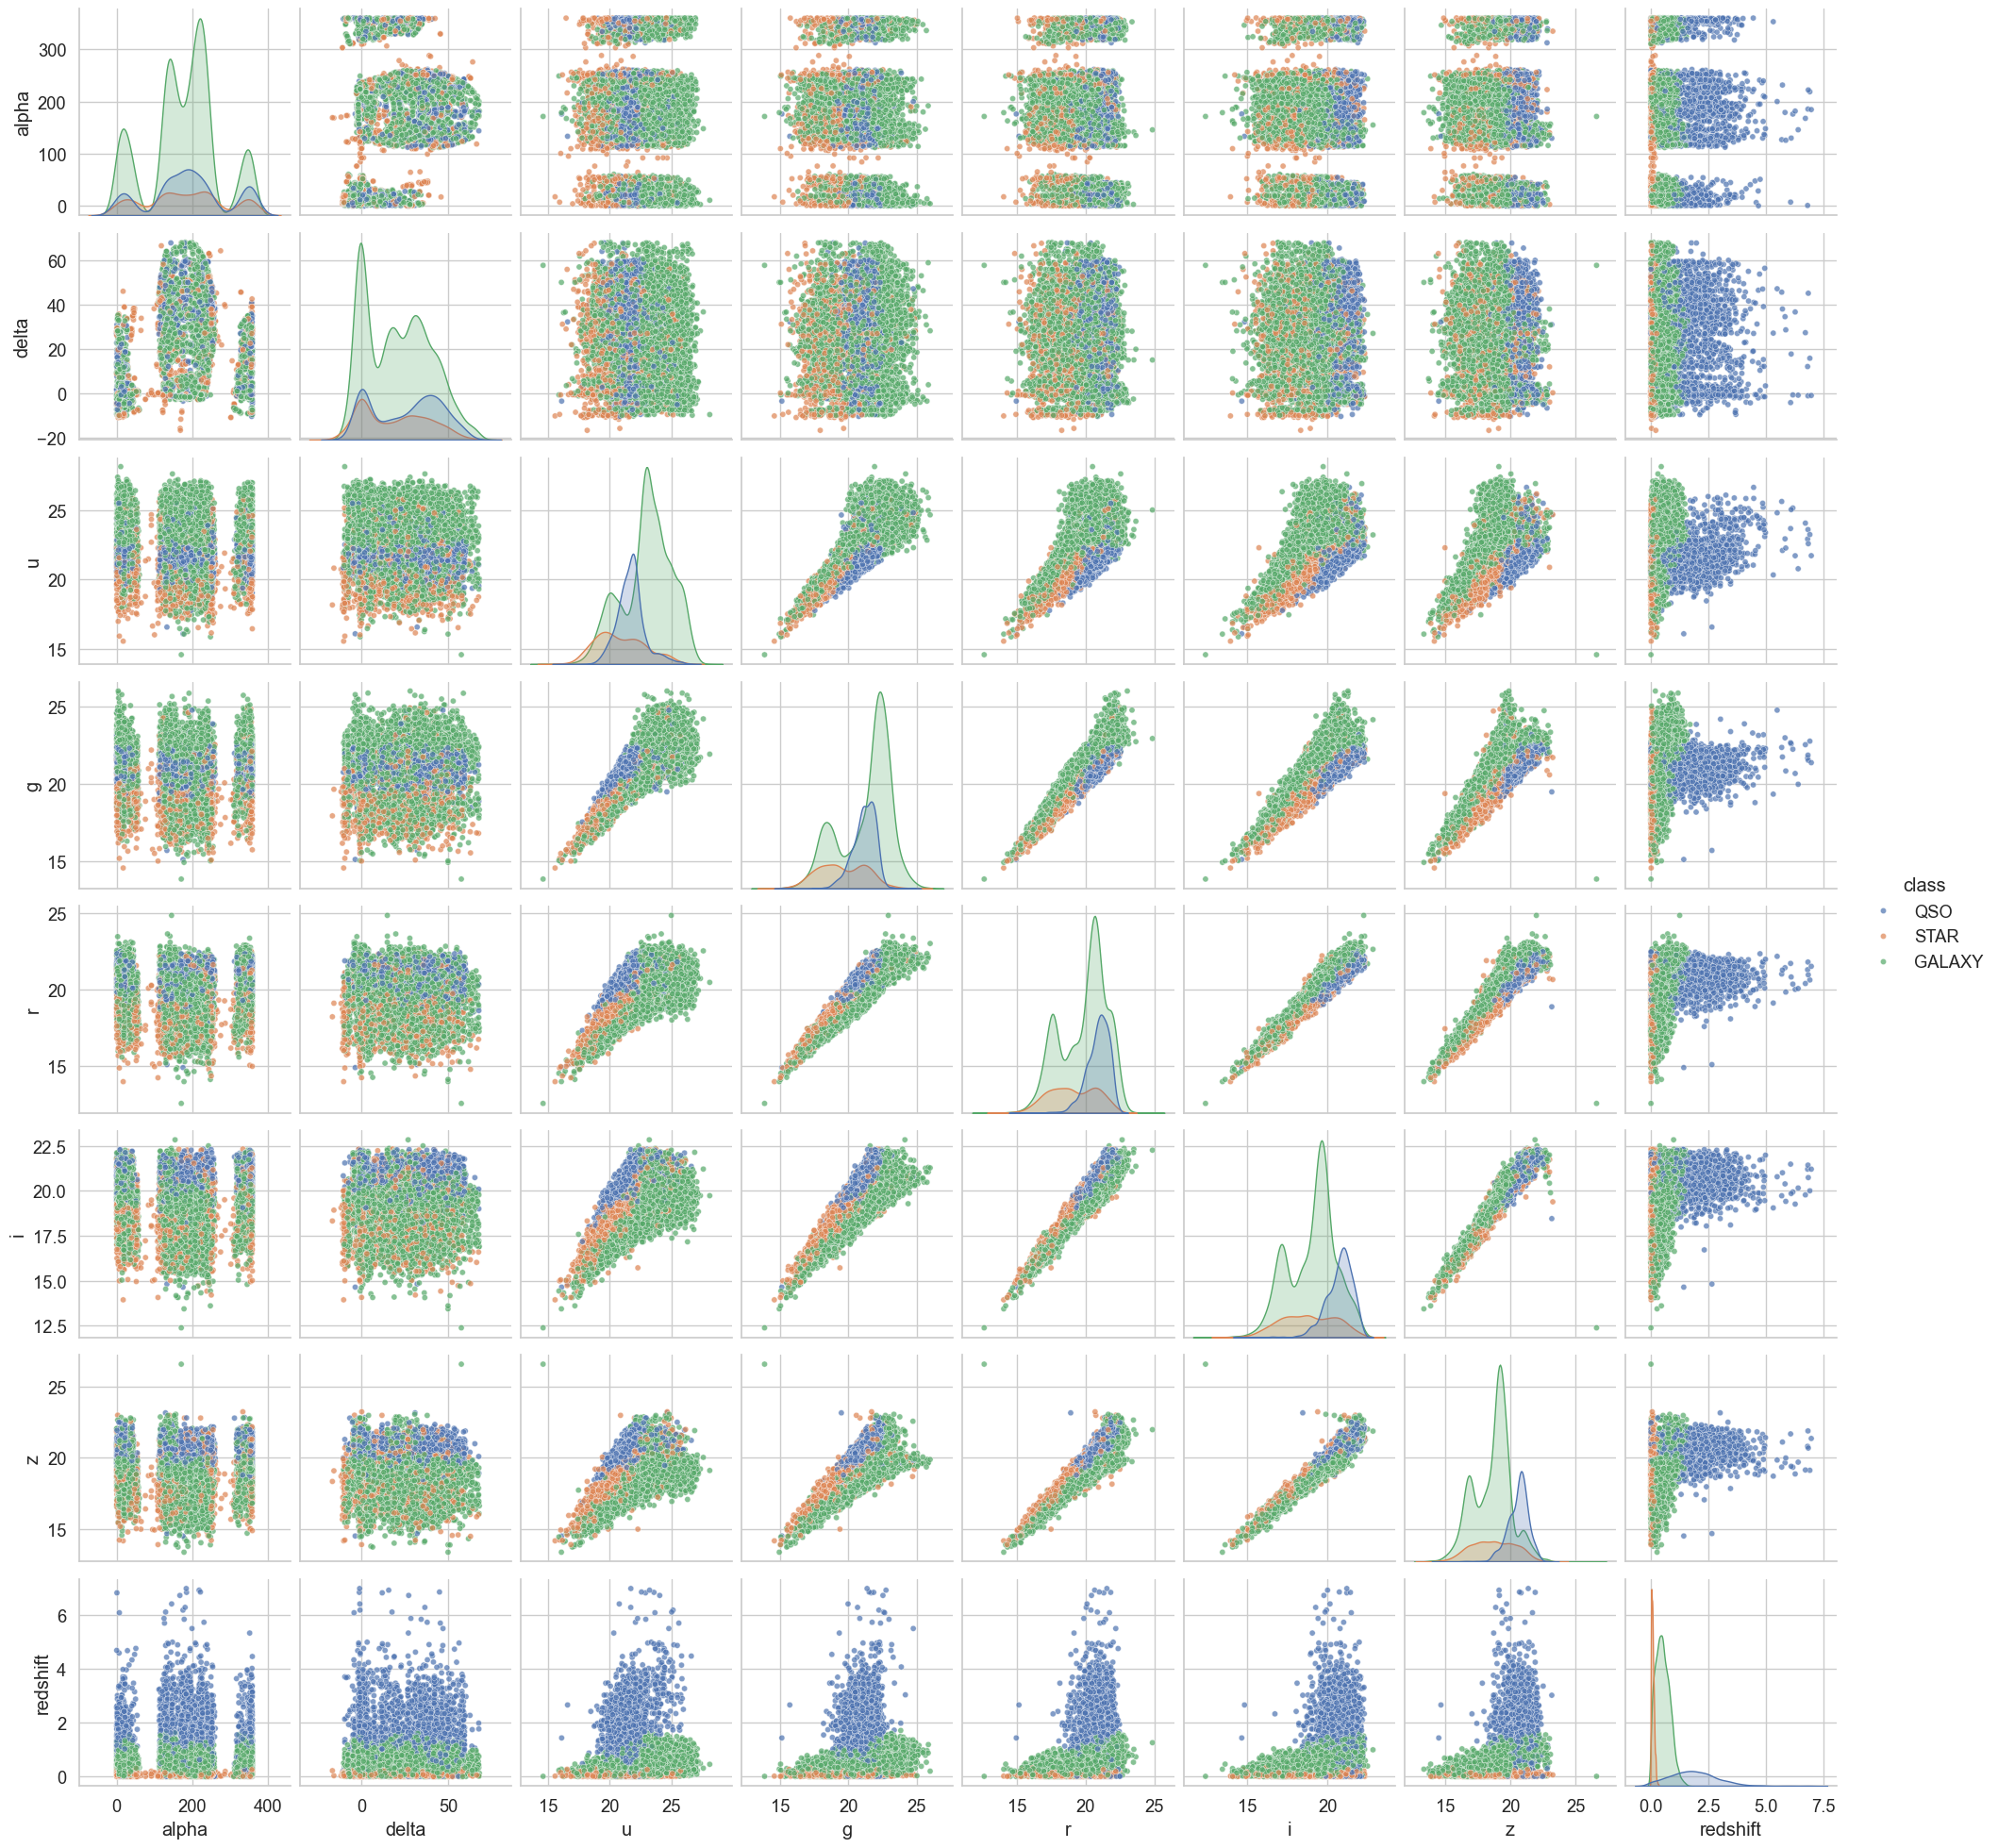

In [12]:
sns.pairplot(df.sample(n=10000, random_state=42)[numeric_cols + ["class"]], hue="class", plot_kws={"s": 20, "alpha": 0.7})
plt.show()

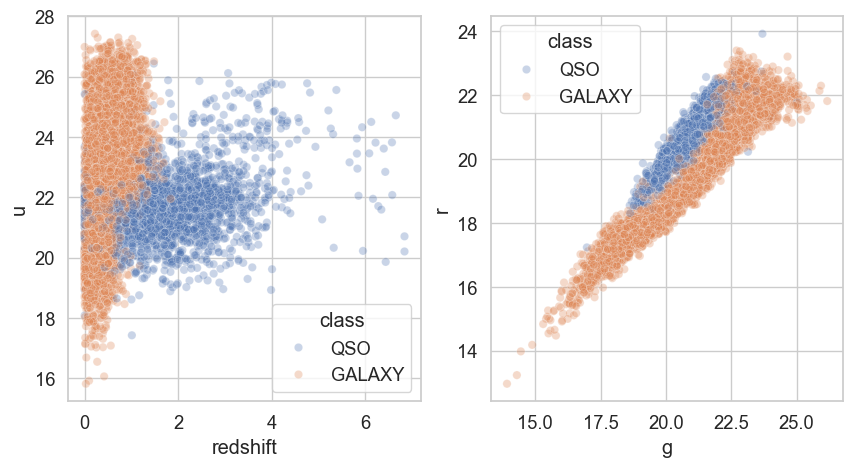

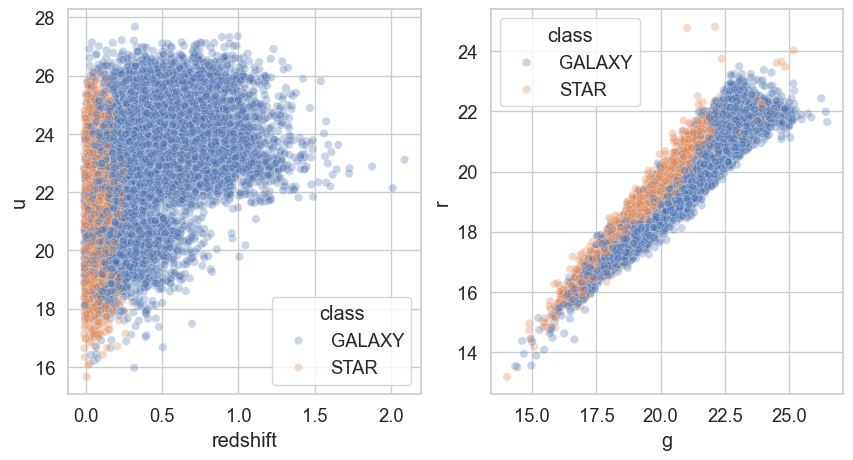

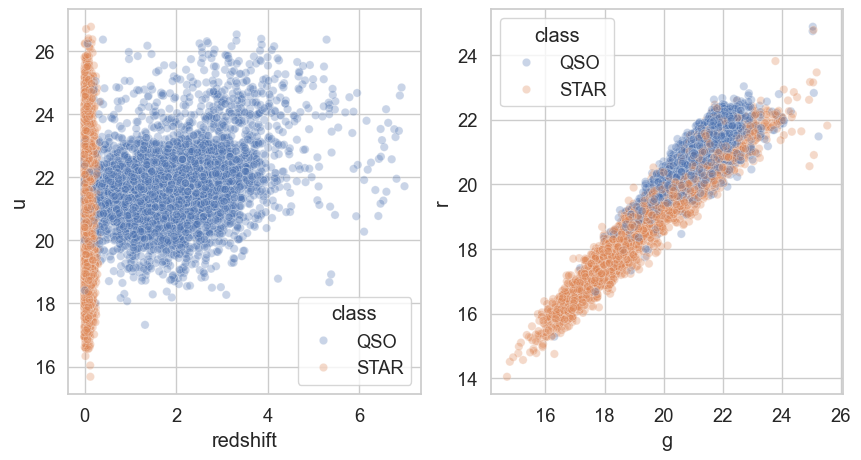

In [13]:
pairs = np.array(list(combinations(df["class"].unique(), 2)))
for n in pairs:
    fig, axes = plt.subplots(1,2, figsize=(10,5))
    sample_df = df[df["class"].isin(n)].sample(10000, random_state=42)
    sns.scatterplot(data = sample_df, x = "redshift", y = "u", hue = "class", ax=axes[0], alpha=0.3)
    sns.scatterplot(data = sample_df, x = "g", y = "r", hue = "class", ax=axes[1], alpha=0.3)
    plt.show()

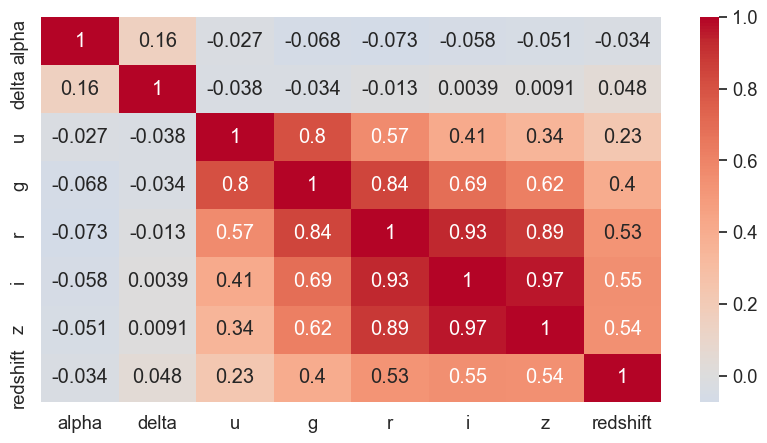

In [14]:
# check spearman for multicolinearity
corr_map = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(10, 5))
sns.heatmap(corr_map, annot=True, cmap="coolwarm", center=0, )
plt.show()

strong multicolineaarity:
    1) u and g
    2) r and g
    3) i and r
    4) z and r
    5) z and i

so potentialy drop: g, r, (i or z)

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_96765/1221337705.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=n, data=df, ax=axes[0], palette="Blues")


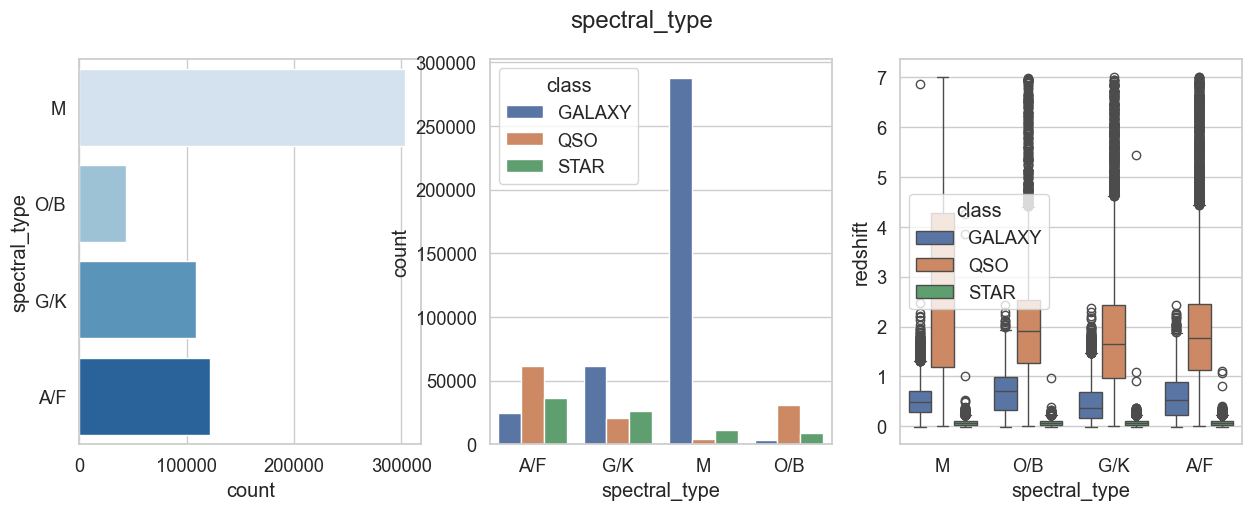

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_96765/1221337705.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=n, data=df, ax=axes[0], palette="Blues")


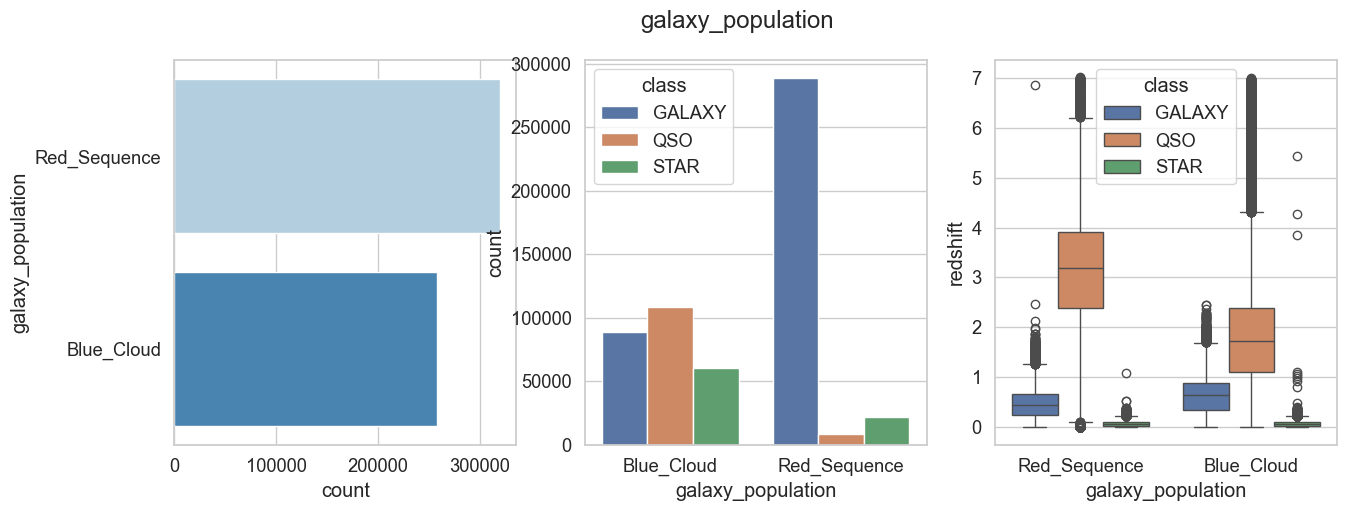

In [15]:
for n in object_cols:
    if n!="class":
        fig, axes = plt.subplots(1,3, figsize=(15,5))
        sns.countplot(y=n, data=df, ax=axes[0], palette="Blues")
        sns.barplot(data=df.groupby([n,"class"]).size().to_frame("count").reset_index(), y="count",x=n, hue="class",  ax=axes[1])

        sns.boxplot(y="redshift", x = n, data=df, hue="class", ax=axes[2])
        fig.suptitle(n)
        plt.show()

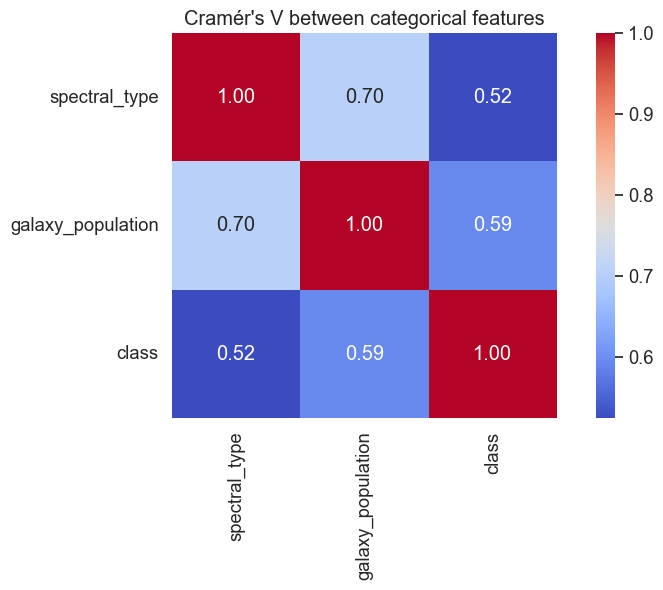

In [16]:
# pairwise cramer for categorical features
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cols = object_cols  +["class"]
cv_matrix = pd.DataFrame(index=cols, columns=cols)

for col1 in cols:
    for col2 in cols:
        cv_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cv_matrix = cv_matrix.astype(float)
plt.figure(figsize=(10, 5))

sns.heatmap(cv_matrix,cmap="coolwarm",annot=True,fmt=".2f",square=True)

plt.title("Cramér's V between categorical features")
plt.show()

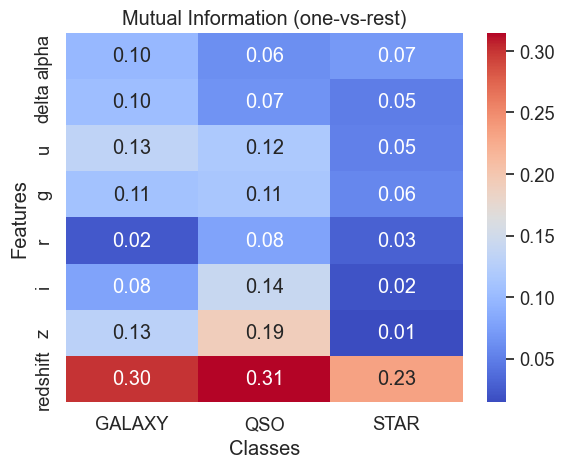

In [17]:
le = LabelEncoder()
y_encoded = le.fit_transform(df["class"])

mi_scores = mutual_info_classif(df[numeric_cols], y_encoded, random_state=42)

mi_df = pd.Series(mi_scores, index=numeric_cols).sort_values(ascending=False)
mi_matrix = pd.DataFrame(index=numeric_cols)

for c in df["class"].unique():
    binary_target = (df["class"] == c).astype(int)
    mi_scores = mutual_info_classif(df[numeric_cols], binary_target, random_state=42)
    mi_matrix[c] = mi_scores

sns.heatmap(mi_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Mutual Information (one-vs-rest)")
plt.ylabel("Features")
plt.xlabel("Classes")
plt.show()

so will probably use:
* redshift
* z
* u
* delta/alpha

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_96765/1794174568.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


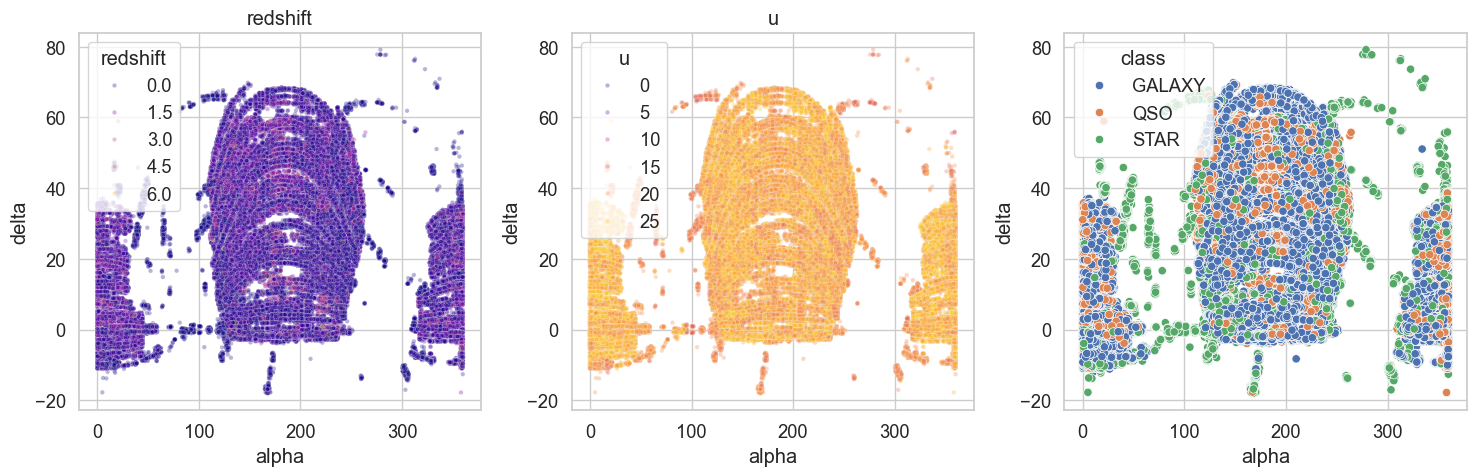

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(data=df,x="alpha",y="delta",hue="redshift",palette="plasma",s=10,alpha=0.3,ax=axes[0])

axes[0].set_title("redshift")

sns.scatterplot(data=df,x="alpha", y="delta",  hue="u",palette="plasma",s=10,alpha=0.3,ax=axes[1])
sns.scatterplot(data=df, x="alpha", y="delta", hue="class", ax=axes[2])
axes[1].set_title("u")

plt.tight_layout()
plt.show()

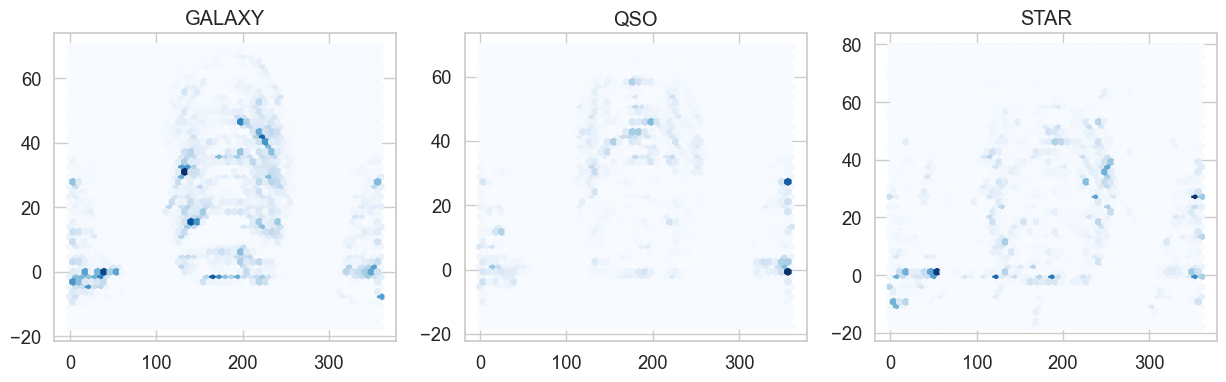

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, cls in zip(axes, ['GALAXY', 'QSO', 'STAR']):
    subset = df[df['class'] == cls]
    ax.hexbin(subset['alpha'], subset['delta'], gridsize=50, cmap='Blues')
    ax.set_title(cls)
plt.show()

## Preprocessing

In [ ]:
def outliers_to_nan(df):
    df = df.copy()
    df.loc[(df["u"] >= 0) & (df["u"] < 2.5), "u"] = np.nan
    df.loc[df["i"] >= 27, "i"] = np.nan    
    return df


In [180]:
class FeatureEngineering(BaseEstimator, TransformerMixin):

    def fit(self, X,  y=None):
        return self
    
    def transform(self, X,y=None):
        X = X.copy()
        # X["low_rdf"] = (X["redshift"]<0.2).astype(int)
        new_cols = ['u-g', 'g-r', 'r-i', 'i-z',]
        X = X.drop(columns=[c for c in new_cols if c in X.columns])

        X['u-g'] = X['u'] - X['g']
        X['g-r'] = X['g'] - X['r']
        X['r-i'] = X['r'] - X['i']
        X['i-z'] = X['i'] - X['z']
        return X


In [190]:
numeric_cols = ['alpha','delta','u','g','r','i','z','redshift','u-g','g-r','r-i','i-z',]

num_pipeline = Pipeline([("fillna", FunctionTransformer(outliers_to_nan)),("imputer", SimpleImputer(strategy="median"))])
cat_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),])
preprocessor = ColumnTransformer([("num", num_pipeline, numeric_cols),("cat", cat_pipeline, object_cols),])
full_pipeline = Pipeline([("feature_engineering", FeatureEngineering()),("preprocessor", preprocessor), ("model", XGBClassifier())])

In [182]:
le = LabelEncoder()
y = le.fit_transform(df["class"])
X_train = df.drop("class", axis=1)

In [183]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [124]:
scores = cross_val_score(full_pipeline, X_train, y, cv=cv, scoring="balanced_accuracy")
print(f"Mean: {scores.mean():.4f} ± {scores.std():.4f}")

Mean: 0.9534 ± 0.0006


* baseline(XGBoos)-0.9528 ± 0.0006
* baseline(XGBoos)+low_rdf-0.9527 ± 0.0006
* baseline(XGBoost)+colors - 0.9534 ± 0.0006

In [132]:
def get_feature_importance(full_pipeline):
    importances_per_fold = []

    for train_idx, val_idx in cv.split(X_train, y):
        X_fold = X_train.iloc[train_idx]  
        y_fold = y[train_idx]        
        
        full_pipeline.fit(X_fold, y_fold)
        model = full_pipeline.named_steps['model']
        importances_per_fold.append(model.feature_importances_)

    cat_features = (full_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(object_cols).tolist())

    all_features = numeric_cols + cat_features

    mean_importance= pd.Series(np.mean(importances_per_fold, axis=0),index=all_features).sort_values(ascending=False)
    return mean_importance

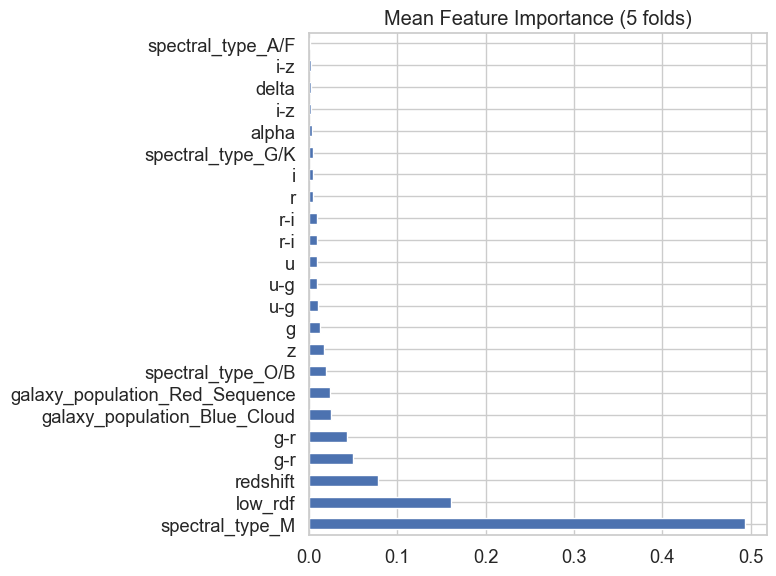

In [134]:

mean_importance_baseline = get_feature_importance(full_pipeline)
mean_importance_baseline.plot(kind='barh', figsize=(8, 6))
plt.title("Mean Feature Importance (5 folds)")
plt.tight_layout()
plt.show()

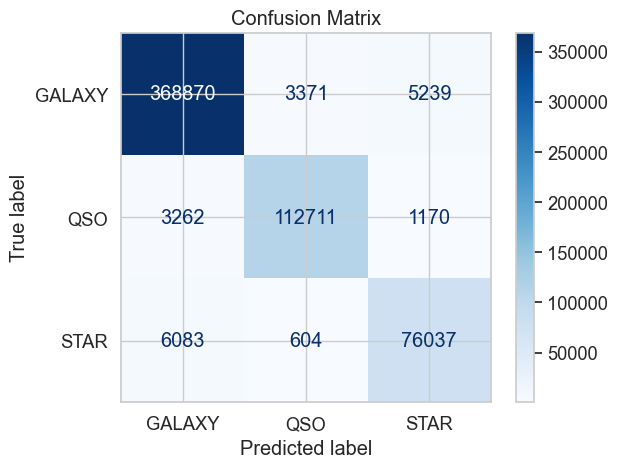

In [52]:
y_hat = cross_val_predict(full_pipeline, X_train, y, cv=cv)

cm=confusion_matrix(y, y_hat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['GALAXY', 'QSO', 'STAR'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

we confuse galaxy and stars the most

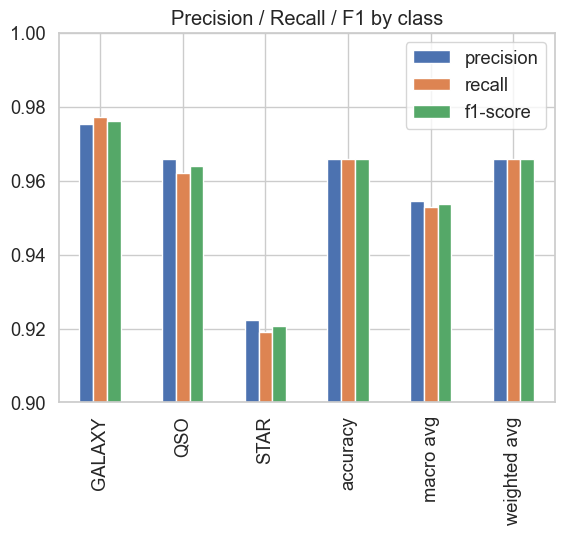

In [28]:
report = classification_report(y, y_hat, target_names=['GALAXY', 'QSO', 'STAR'],output_dict=True)
pd.DataFrame(report).T.drop('support', axis=1).plot(kind='bar')
plt.title("Precision / Recall / F1 by class")
plt.ylim(0.9, 1.0)  
plt.show()

## Error analysis

In [29]:
df["predicted_class"] = le.inverse_transform(y_hat)

In [40]:
missclassified_df=df[df["class"]!=df["predicted_class"]]
correct_df=df[df["class"]==df["predicted_class"]]

In [64]:
galaxy_as_stars = missclassified_df[(missclassified_df["predicted_class"]=="STAR") & (missclassified_df["class"]=="GALAXY")]
stars_as_galaxy = missclassified_df[(missclassified_df["predicted_class"]=="GALAXY") & (missclassified_df["class"]=="STAR")]


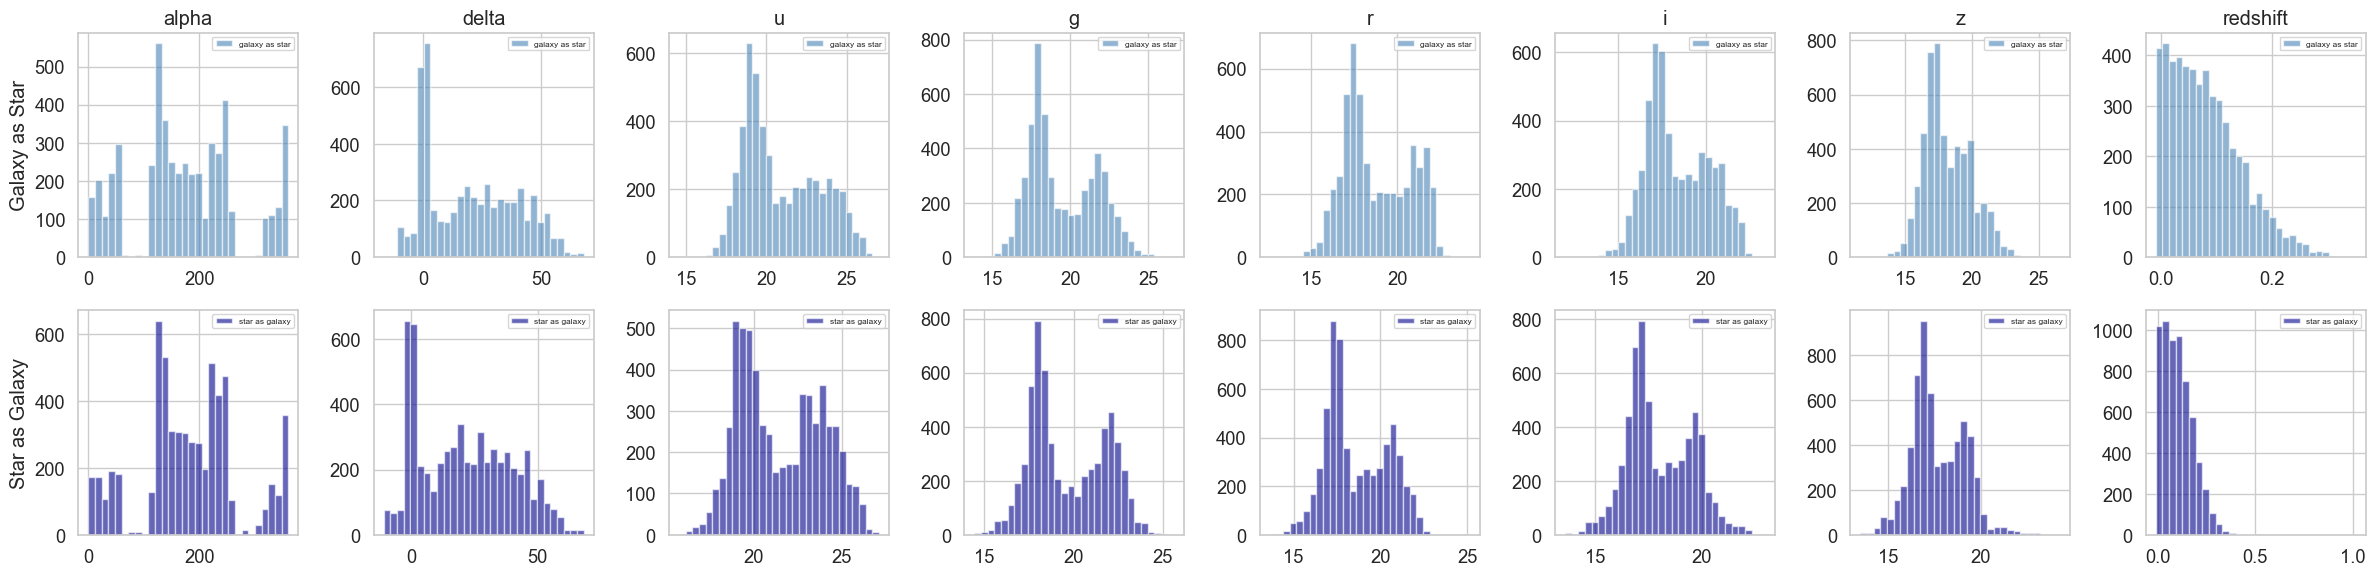

In [ ]:
error_pairs = {'Galaxy as Star': galaxy_as_stars,'Star as Galaxy': stars_as_galaxy,}

fig, axes = plt.subplots(2, len(numeric_cols), figsize=(len(numeric_cols) * 3, 6))

for col, feature in enumerate(numeric_cols):
    axes[0, col].hist(galaxy_as_stars[feature], bins=30, alpha=0.6, color='steelblue', label='galaxy as star')
    axes[0, col].set_title(feature)
    axes[0, col].legend(fontsize=6)
    if col == 0:
        axes[0, col].set_ylabel('Galaxy as Star')

    axes[1, col].hist(stars_as_galaxy[feature],bins=30, alpha=0.6, color='darkblue', label='star as galaxy')
    axes[1, col].legend(fontsize=6)
    if col == 0:
        axes[1, col].set_ylabel('Star as Galaxy')

plt.tight_layout()
plt.show()


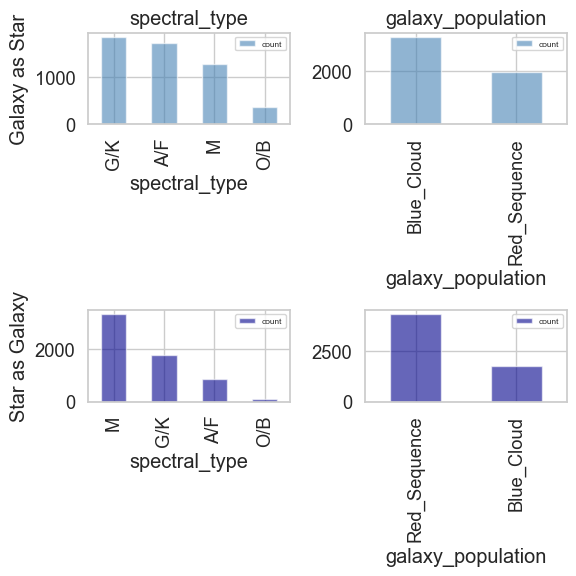

In [ ]:
fig, axes = plt.subplots(2, len(object_cols), figsize=((len(object_cols)) * 3, 6))


for col, feature in enumerate(object_cols):
   
    galaxy_as_stars[feature].value_counts().plot(kind='bar', ax=axes[0, col], color='steelblue', alpha=0.6)
    stars_as_galaxy[feature].value_counts().plot(kind='bar', ax=axes[1, col], color='darkblue', alpha=0.6)

    axes[0, col].set_title(feature)
    axes[0, col].legend(fontsize=6)
    axes[1, col].legend(fontsize=6)
    if col == 0:
        axes[0, col].set_ylabel('Galaxy as Star')
        axes[1, col].set_ylabel('Star as Galaxy')

plt.tight_layout()
plt.show()

In [ ]:
X_train

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type',
       'galaxy_population', 'predicted_class', 'low_rdf'],
      dtype='object')

### Param tuning

In [127]:
def objective(trial):
    params = {
        "model__n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "model__max_depth": trial.suggest_int("max_depth", 3, 10),
        "model__learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "model__subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "model__colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "model__reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "model__reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "model__min_child_weight": trial.suggest_int("min_child_weight", 1, 10),}
    
    full_pipeline.set_params(**params)
    
    scores = cross_val_score(full_pipeline, X_train, y,cv=cv,scoring='balanced_accuracy',n_jobs=-1)
    return scores.mean()

In [ ]:
full_pipeline_baseline = Pipeline([("feature_engineering", FeatureEngineering()),("preprocessor", preprocessor), ("model", XGBClassifier())])

In [128]:
study = optuna.create_study(direction="maximize",sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest score: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best score: 0.9552
Best params: {'n_estimators': 408, 'max_depth': 9, 'learning_rate': 0.06517285686059575, 'subsample': 0.9294757687866327, 'colsample_bytree': 0.717524284541237, 'reg_alpha': 0.005491974844852558, 'reg_lambda': 0.004989113998677421, 'min_child_weight': 10}


* XGBoost tuned  - 0.9552

In [184]:
best_params = {f"model__{k}": v for k, v in study.best_params.items()}
full_pipeline_tuned = Pipeline([("feature_engineering", FeatureEngineering()),("preprocessor", preprocessor), ("model", XGBClassifier())])
full_pipeline_tuned.set_params(**best_params)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [140]:
mean_importance_tuned = get_feature_importance(full_pipeline_tuned)


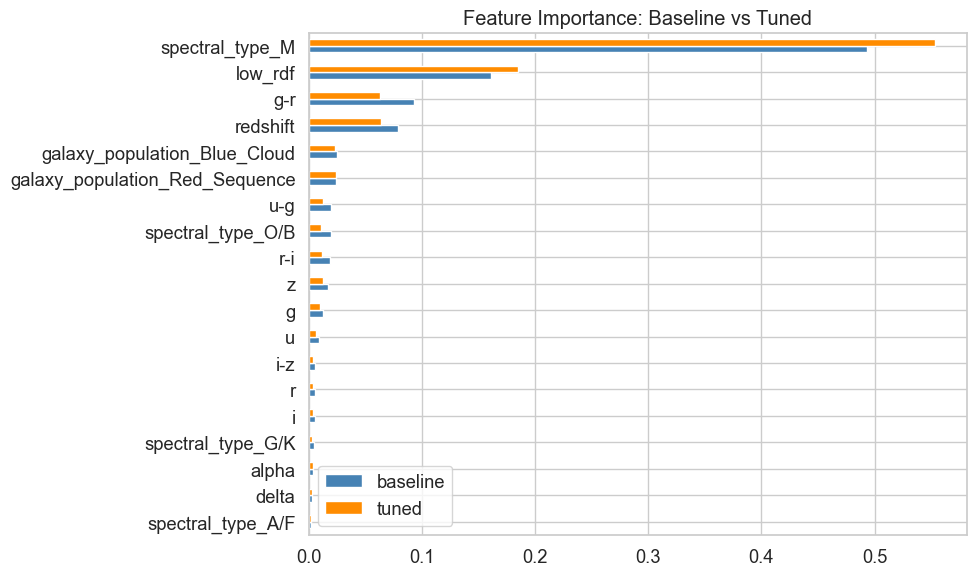

In [145]:
comparison = pd.DataFrame({'baseline': mean_importance_baseline,'tuned': mean_importance_tuned}).sort_values('baseline')

comparison.plot(kind='barh', figsize=(10, 6), color=['steelblue', 'darkorange'])
plt.title("Feature Importance: Baseline vs Tuned")
plt.tight_layout()
plt.savefig("comparison_baseline_tuned.png")
plt.show()

## Different models

In [169]:
X_train = df.drop(["class", "predicted_class"], axis=1)

In [170]:
def make_pipeline(model):
    pipeline = Pipeline([("feature_engineering", FeatureEngineering()),("preprocessor", preprocessor), ("model", model)])
    return pipeline

def run_model(model, name):
    pipeline = make_pipeline(model)
    scores = cross_val_score(pipeline, X_train, y,cv=cv, scoring='balanced_accuracy')
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores.mean()


XGBoost: 0.9534 ± 0.0006
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004262 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4094
[LightGBM] [Info] Number of data points in the train set: 461877, number of used features: 23
[LightGBM] [Info] Start training from score -0.424925
[LightGBM] [Info] Start training from score -1.595051
[LightGBM] [Info] Start training from score -1.942935


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4094
[LightGBM] [Info] Number of data points in the train set: 461877, number of used features: 23
[LightGBM] [Info] Start training from score -0.424925
[LightGBM] [Info] Start training from score -1.595051
[LightGBM] [Info] Start training from score -1.942935


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004386 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4094
[LightGBM] [Info] Number of data points in the train set: 461878, number of used features: 23
[LightGBM] [Info] Start training from score -0.424927
[LightGBM] [Info] Start training from score -1.595053
[LightGBM] [Info] Start training from score -1.942922


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004151 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4094
[LightGBM] [Info] Number of data points in the train set: 461878, number of used features: 23
[LightGBM] [Info] Start training from score -0.424927
[LightGBM] [Info] Start training from score -1.595043
[LightGBM] [Info] Start training from score -1.942938


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4094
[LightGBM] [Info] Number of data points in the train set: 461878, number of used features: 23
[LightGBM] [Info] Start training from score -0.424927
[LightGBM] [Info] Start training from score -1.595043
[LightGBM] [Info] Start training from score -1.942938


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: 0.9514 ± 0.0008
CatBoost: 0.9514 ± 0.0005
RandomForest: 0.9412 ± 0.0007


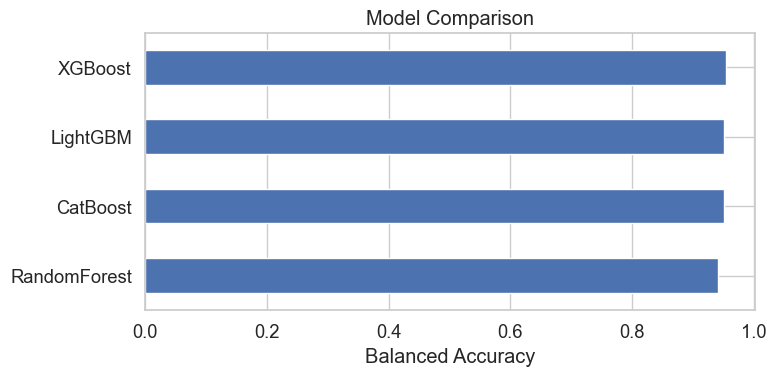

In [148]:
results = {}
results['XGBoost'] = run_model(XGBClassifier(), 'XGBoost')
results['LightGBM'] = run_model(LGBMClassifier(), 'LightGBM')
results['CatBoost'] = run_model(CatBoostClassifier(verbose=0), 'CatBoost')
results['RandomForest'] = run_model(RandomForestClassifier(), 'RandomForest')

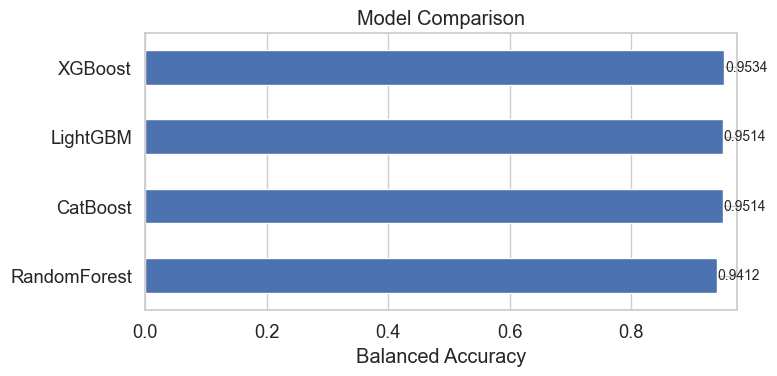

In [151]:
ax = pd.Series(results).sort_values().plot(kind='barh', figsize=(8, 4))

for i, (name, score) in enumerate(pd.Series(results).sort_values().items()):
    ax.text(score + 0.001, i, f'{score:.4f}', va='center', fontsize=10)

plt.title("Model Comparison")
plt.xlabel("Balanced Accuracy")
plt.xlim(0, pd.Series(results).max() + 0.02)  
plt.tight_layout()
plt.savefig("baseline_model_comparison.png")
plt.show()

## LightGBM tuning

In [171]:
def objective_lgbm(trial):
    params = {
        "model__n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "model__max_depth": trial.suggest_int("max_depth", 3, 10),
        "model__learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "model__subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "model__colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "model__reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "model__reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "model__num_leaves": trial.suggest_int("num_leaves", 20, 100),}
    
    pipeline_lgbm = make_pipeline(LGBMClassifier(**{k.replace("model__", ""): v for k, v in params.items()},verbose=-1 ))
    
    scores = cross_val_score(pipeline_lgbm, X_train, y,cv=cv, scoring='balanced_accuracy')
    return scores.mean()

In [156]:
study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)
print(f"LightGBM best: {study_lgbm.best_value:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/

LightGBM best: 0.9561


LightGBM best: 0.9561

In [185]:
best_params_lgbm = {f"model__{k}": v for k, v in study.best_params.items()}

In [ ]:

ensemble = VotingClassifier(estimators=[('xgb', make_pipeline(XGBClassifier(**best_params))),('lgbm', make_pipeline(LGBMClassifier(**best_params_lgbm, verbose=-1))),('catboost', make_pipeline(CatBoostClassifier(verbose=0))),],voting='soft')
scores = cross_val_score(ensemble, X_train, y,cv=cv, scoring='balanced_accuracy')
print(f"Ensemble: {scores.mean():.4f} ± {scores.std():.4f}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [18:40:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "model__colsample_bytree", "model__learning_rate", "model__max_depth", "model__min_child_weight", "model__n_estimators", "model__reg_alpha", "model__reg_lambda", "model__subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [18:42:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "model__colsample_bytree", "model__learning_rate", "model__max_depth", "model__min_child_weight", "model__n_esti

Ensemble: 0.9535 ± 0.0004


## Final predictions

In [191]:
X_test = pd.read_csv("data/test.csv")

In [192]:
ensemble = VotingClassifier(estimators=[('xgb', make_pipeline(XGBClassifier(**best_params))),('lgbm', make_pipeline(LGBMClassifier(**best_params_lgbm, verbose=-1))),('catboost', make_pipeline(CatBoostClassifier(verbose=0))),],voting='soft')

ensemble.fit(X_train, y)
preds = ensemble.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:00:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "model__colsample_bytree", "model__learning_rate", "model__max_depth", "model__min_child_weight", "model__n_estimators", "model__reg_alpha", "model__reg_lambda", "model__subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
preds_labels = le.inverse_transform(preds)
submission = pd.DataFrame({'id': X_test['id'],'class': preds_labels})

submission.to_csv('submission.csv', index=False)

       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
(247435, 2)
